### This example demostrates how to use SHAP to explain the effects in a machine learning model.

Here we use XGBoost as an example. SHAP has an unique `TreeExplainer` that can efficiently explain Tree-based models. You can explore SHAP usage on other types of model on its website.https://shap.readthedocs.io/en/latest/

SHAP has other estimators such as KernelSHAP which can be model-agnostic (works for any models).

We will re-use the same house price data for demostration.

In [1]:
#pip install shap

In [2]:
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

### Data

In [6]:
houses = pd.read_csv("https://raw.githubusercontent.com/Ziqi-Li/GIS5122/spring-25/data/seattle_sample_1k.csv")

In [7]:
houses.head()

,Unnamed: 0,bathrooms,sqft_living,sqft_lot,grade,condition,waterfront,view,age,UTM_X,UTM_Y,log_price
0,0,3.00,2660,4600,8,3,0,0,109,552217.557035,5.274945e+06,6.091315
1,1,2.25,2530,8736,7,4,0,0,57,565692.484331,5.272758e+06,5.790988
2,2,2.00,1390,13464,7,4,0,0,28,562451.661509,5.245291e+06,5.315130
3,3,1.00,940,4264,7,5,0,0,66,546816.935618,5.264407e+06,5.619093
4,4,2.25,2070,7225,8,3,0,0,36,564343.195352,5.244978e+06,5.477121


In [9]:
#Usually we want to log the skewed variable for the model to easier be optimized
#But here I reverted it back to dollar value for simpler interpretation.
y = 10**houses.log_price/1000

X = houses[['bathrooms', 'sqft_living', 'sqft_lot', 'grade',
       'condition', 'waterfront', 'view', 'age', 'UTM_X', 'UTM_Y']]

In [10]:
X.describe()

,bathrooms,sqft_living,sqft_lot,grade,condition,waterfront,view,age,UTM_X,UTM_Y
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,2.040500,1954.711000,7437.067000,7.508000,3.470000,0.008000,0.219000,49.094000,555090.973162,5.269253e+06
std,0.771739,795.175658,3541.230107,1.083102,0.695402,0.089129,0.737281,29.047563,6811.126645,1.504789e+04
min,0.750000,580.000000,651.000000,5.000000,1.000000,0.000000,0.000000,0.000000,542351.561206,5.234196e+06
25%,1.500000,1380.000000,5000.000000,7.000000,3.000000,0.000000,0.000000,25.000000,549352.543915,5.259722e+06
50%,2.000000,1800.000000,7350.000000,7.000000,3.000000,0.000000,0.000000,50.000000,553361.945522,5.270805e+06
75%,2.500000,2382.500000,9376.250000,8.000000,4.000000,0.000000,0.000000,67.000000,561191.194563,5.281673e+06
max,5.250000,5540.000000,19991.000000,12.000000,5.000000,1.000000,4.000000,115.000000,569768.086080,5.291748e+06


We can split the data into training (80%) and testing (20%). The model will be trained based on the training data and the testing data will be used to evaluate the model accuracy on unseen data.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## AutoML to tune an XGBoost model

In [16]:
from flaml import AutoML


settings = {
    "time_budget": 20,  # total running time in seconds
    "metric": 'r2',  # primary metrics for regression can be chosen from: ['mae','mse','r2','rmse','mape']
    "estimator_list": ['xgboost'],  # list of ML learners; 'auto' means try all
    "task": 'regression',  # task type, can also be classification   
    "eval_method": 'cv', #enable cross-validation
    "n_splits": 5 #5-fold cross validation
}

automl = AutoML()
automl.fit(X_train, y_train,  **settings)

[flaml.automl.logger: 03-31 17:20:27] {1728} INFO - task = regression
[flaml.automl.logger: 03-31 17:20:27] {1739} INFO - Evaluation method: cv
[flaml.automl.logger: 03-31 17:20:27] {1838} INFO - Minimizing error metric: 1-r2
[flaml.automl.logger: 03-31 17:20:27] {1955} INFO - List of ML learners in AutoML Run: ['xgboost']
[flaml.automl.logger: 03-31 17:20:27] {2258} INFO - iteration 0, current learner xgboost
[flaml.automl.logger: 03-31 17:20:27] {2393} INFO - Estimated sufficient time budget=354s. Estimated necessary time budget=0s.
[flaml.automl.logger: 03-31 17:20:27] {2442} INFO -  at 0.1s,	estimator xgboost's best error=0.7035,	best estimator xgboost's best error=0.7035
[flaml.automl.logger: 03-31 17:20:27] {2258} INFO - iteration 1, current learner xgboost
[flaml.automl.logger: 03-31 17:20:27] {2442} INFO -  at 0.1s,	estimator xgboost's best error=0.7035,	best estimator xgboost's best error=0.7035
[flaml.automl.logger: 03-31 17:20:27] {2258} INFO - iteration 2, current learner x

### XGBoost

In [18]:
xgb_pred = automl.predict(X_test)

In [19]:
from sklearn.metrics import r2_score
r2_score(y_test, xgb_pred)

0.8276298230309305

The model has an R2 value of 0.827 for the test data.

### SHAP explanations

In [20]:
#Installation
#pip install shap

In [21]:
import shap

In [28]:
best_xgb = automl.model.estimator

In [29]:
# Initialize the TreeExplainer with the best trained XGBoost model
explainer = shap.TreeExplainer(best_xgb)

# Compute SHAP values for the entire dataset. You can also just compute for the test dataset.
shap_values = explainer(X)

[17:23:13] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.


Remember the predicted value is a sum of a base_value and Shap value for each feature.

y_pred = base_value + Σj SHAP_Feature_j

Below we prove this:

In [30]:
#Right hand side
total_shap = (shap_values.base_values + shap_values.values.sum(axis=1))

In [31]:
#Left hand side
total_y_pred = best_xgb.predict(X)

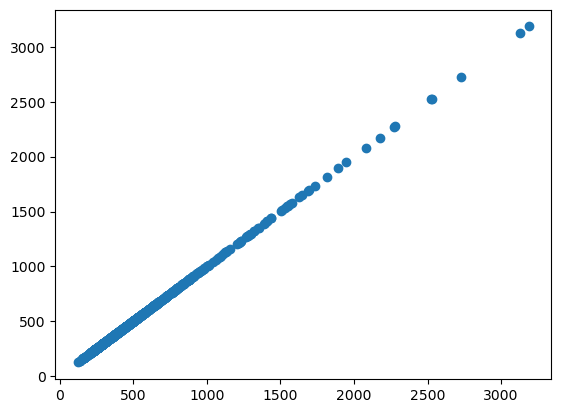

In [32]:
plt.scatter(total_y_pred, total_shap)

### SHAP results

Below is a shap summary plot:
- The x-axis is the SHAP value. Remember, SHAP values are in the same unit of your y variable. Here we have 1 unit of SHAP value interpretated as 1k dollars.
- The y axis is a ranking of the most important to the least important vairable from top to bottom. The importance is measured by the average absolute SHAP value. Here UTM_Y (the UTM Y coordinate of the property location) is the most important variable. 
- The color of the dots are the features values with high value in red and low value in blue.
- From the color we can observe some general relationships, here I just list some examples:
    - UTM_Y: As the house is moving from south to north, the SHAP value increases, indicating houses in the northern Seattle are more expensive than houses in southern Seattle.
    - Grade: As grade increases (blue to red), SHAP value increases (left to right), indicating grade and grade's SHAP value have a positive relationship, i.e. higher-grade property will have higher property price.
    - Waterfront: since this is a binary variable, blue will be 0 (w/o waterfront) and red will be 1 (w waterfront) so property with waterfont (red dots) show they increase property price by ~200k dollars.
    - You can extrapolate these observations for other features.

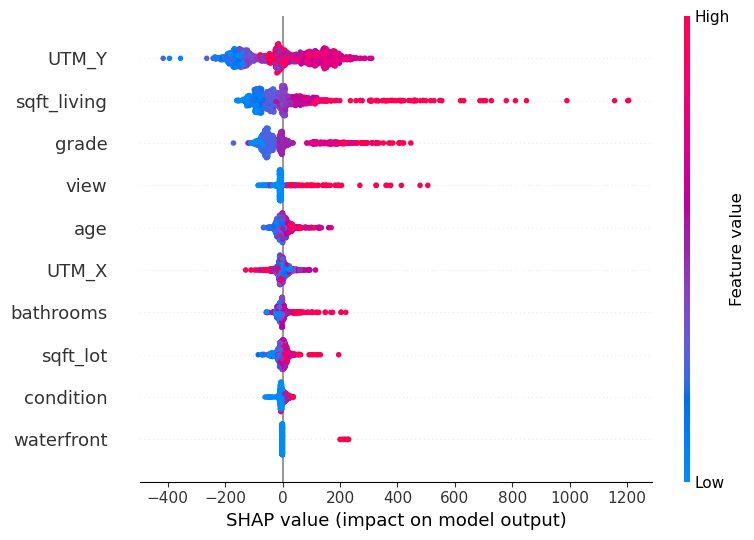

In [33]:
shap.summary_plot(shap_values, X)

Due to the local nature of SHAP values, we can observe how housing attributes determine the price for each individual house. The notation f(x) represents the model's predicted value for a house, while E(f(x)) denotes the average predicted house value. 


A feature colored red indicates a positive contribution, and one colored blue signifies a negative contribution to the difference between the predicted house price and the average predicted house price for the entire Seattle area. These SHAP values explain why the price of a certain house is higher, lower, or similar to the average house price.

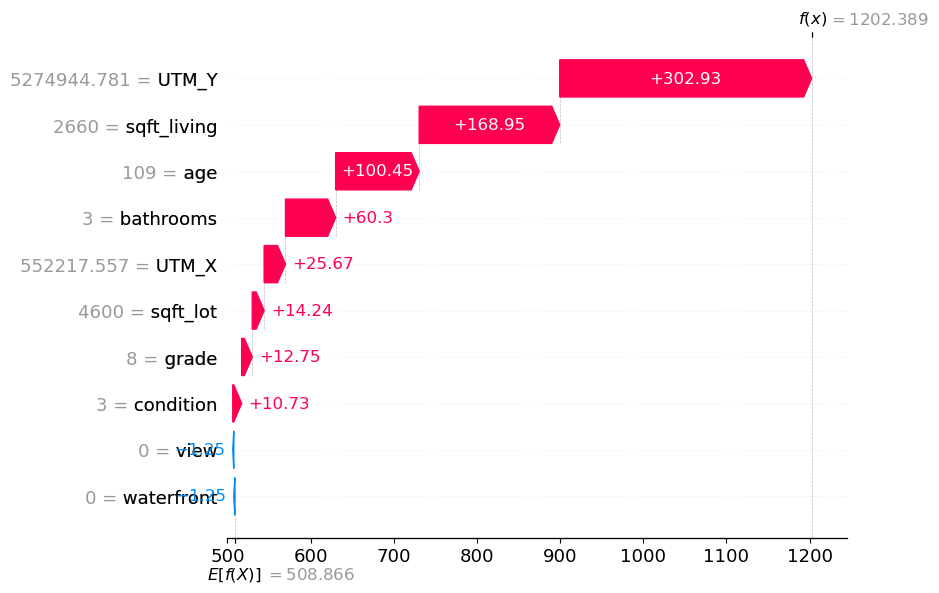

In [34]:
shap.plots.waterfall(shap_values[0])

We can examine another house

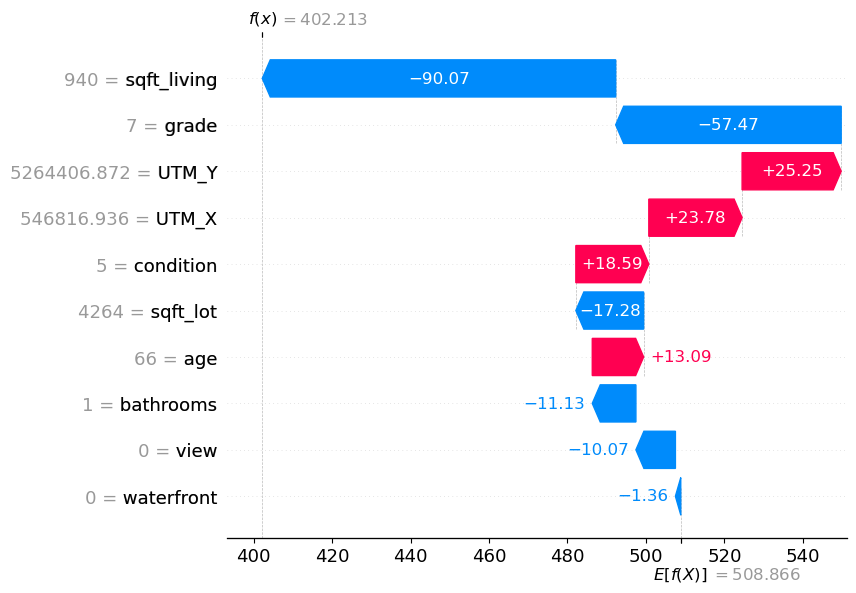

In [35]:
shap.plots.waterfall(shap_values[3])

Next we can plot partial dependence plots which each shows the relatipnship between the feature and its impact/contribution to the house price. We can observe, the shape (lienarity/non-lienarity), magitude (value on the y-axis) and trend (positive/negative) of relationships from these plots.

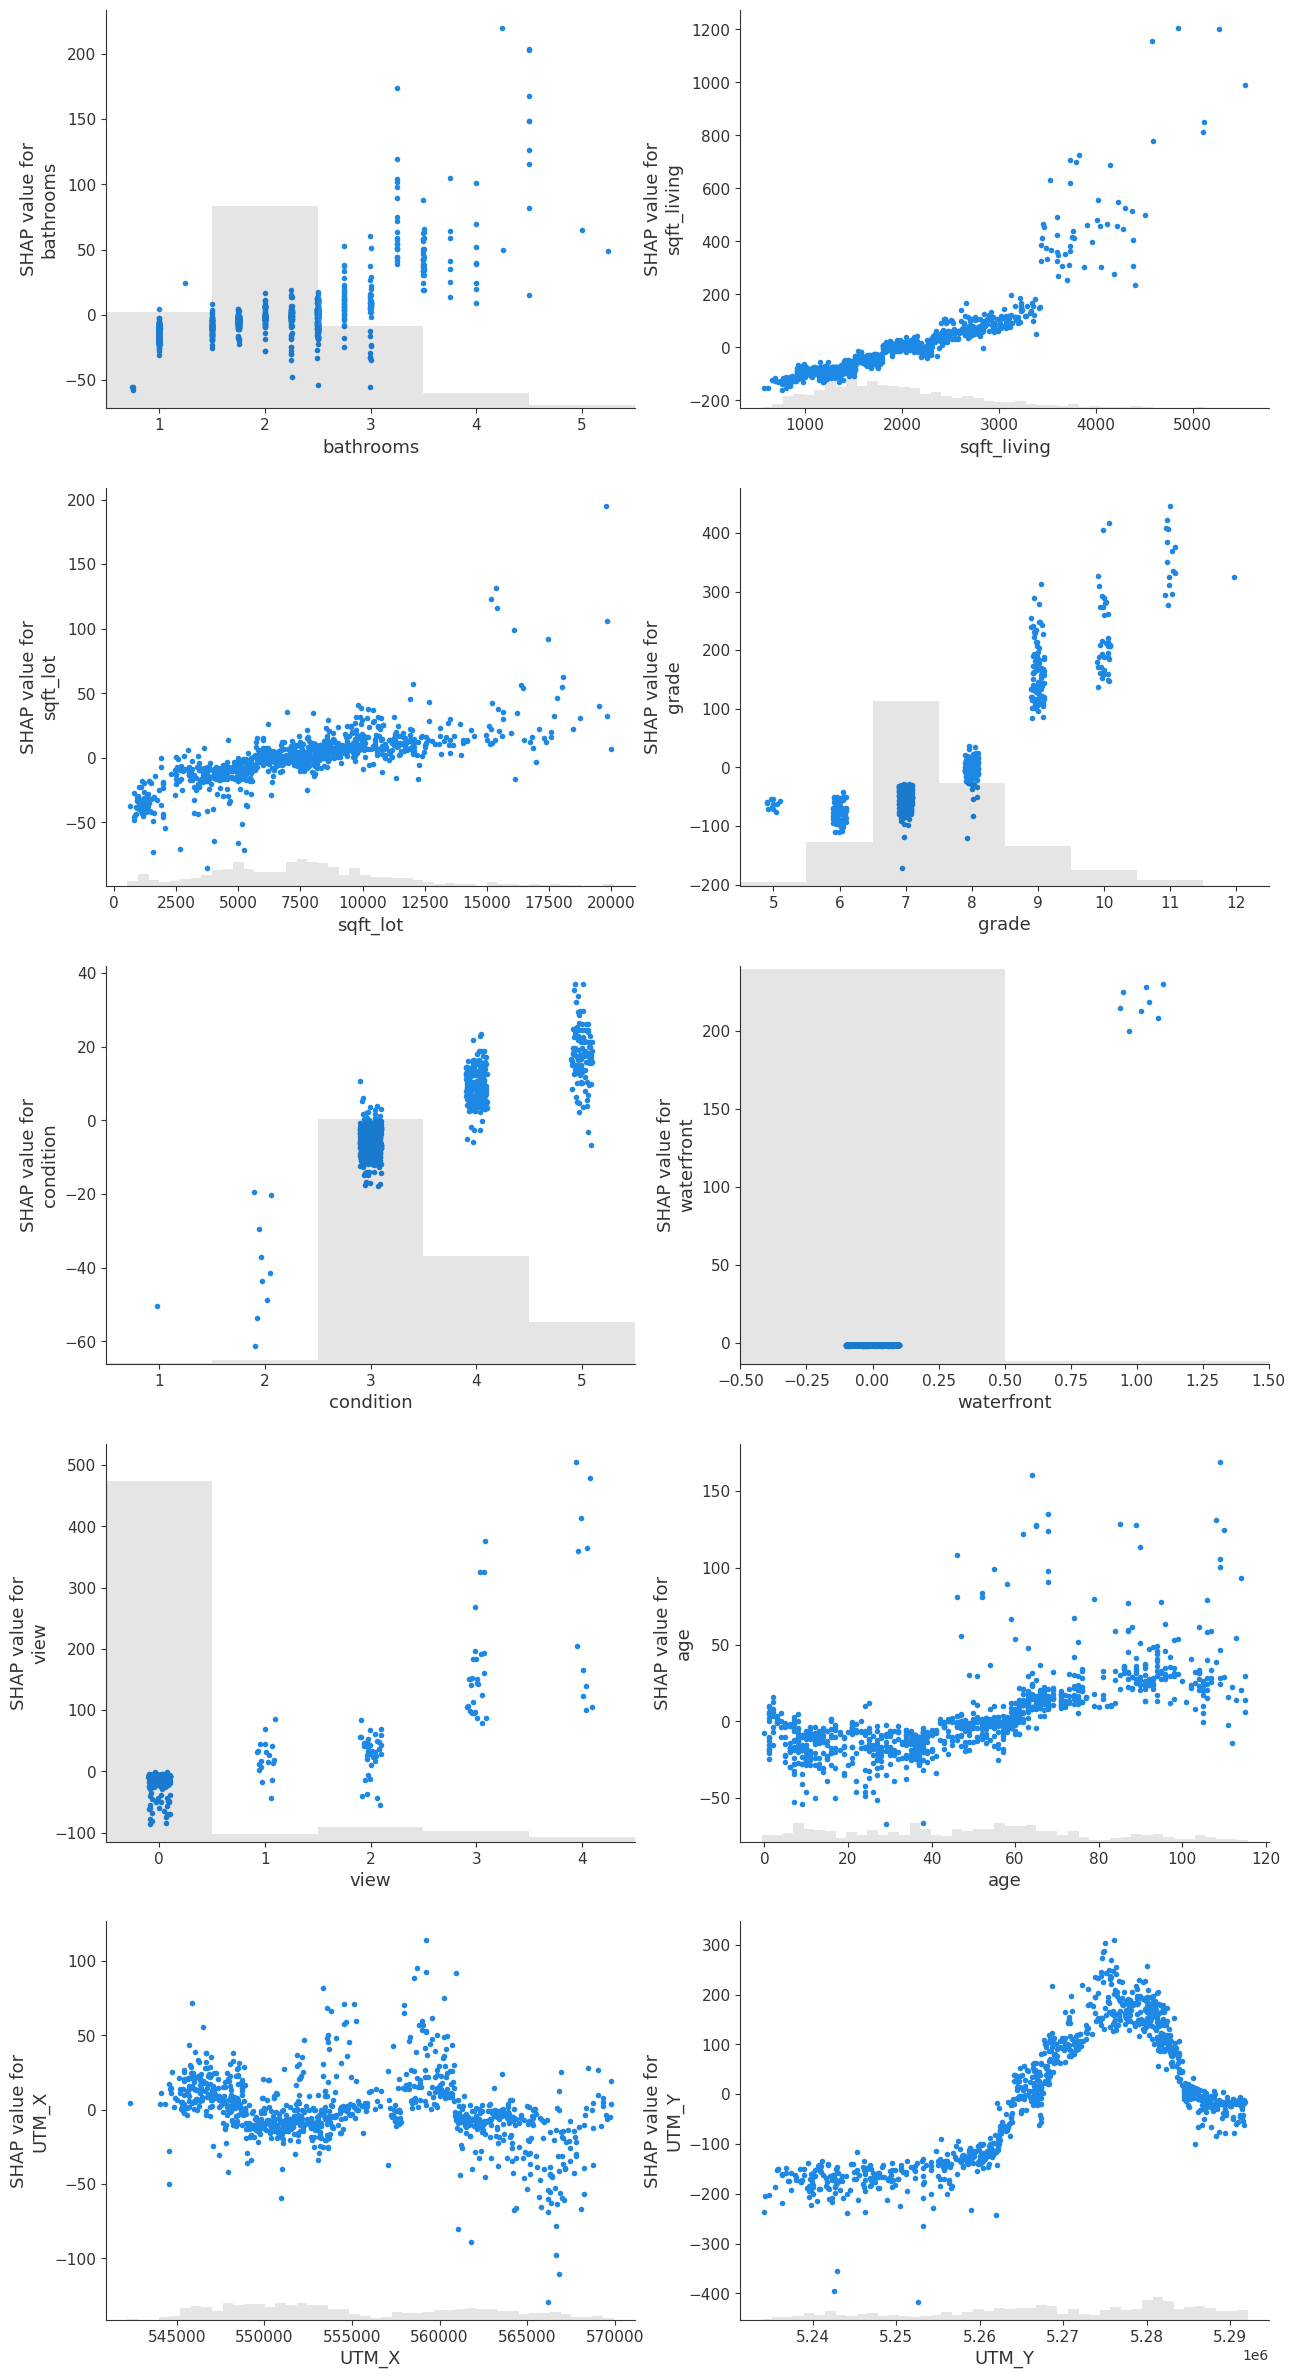

In [36]:
n_rows = 5
n_cols = 2

fig, axs = plt.subplots(n_rows, n_cols, figsize=(15, 30))  # Create a grid of subplots

for i, ax in enumerate(axs.flat):
    shap.plots.scatter(shap_values[:,i],ax=ax,show=False)

Lastly, we can make a map of the combined contribution from both UTM_X and UTM_Y, which measures how location/context (neighborhood, amenity, preference etc.) affects the house price prediction.

In [37]:
import geopandas as gpd
import contextily as cx

sea_map = gpd.GeoDataFrame(
    X, crs="EPSG:32610", geometry=gpd.points_from_xy(x=X.UTM_X, y=X.UTM_Y))
#sea_map = sea_map.to_crs("EPSG:4326")

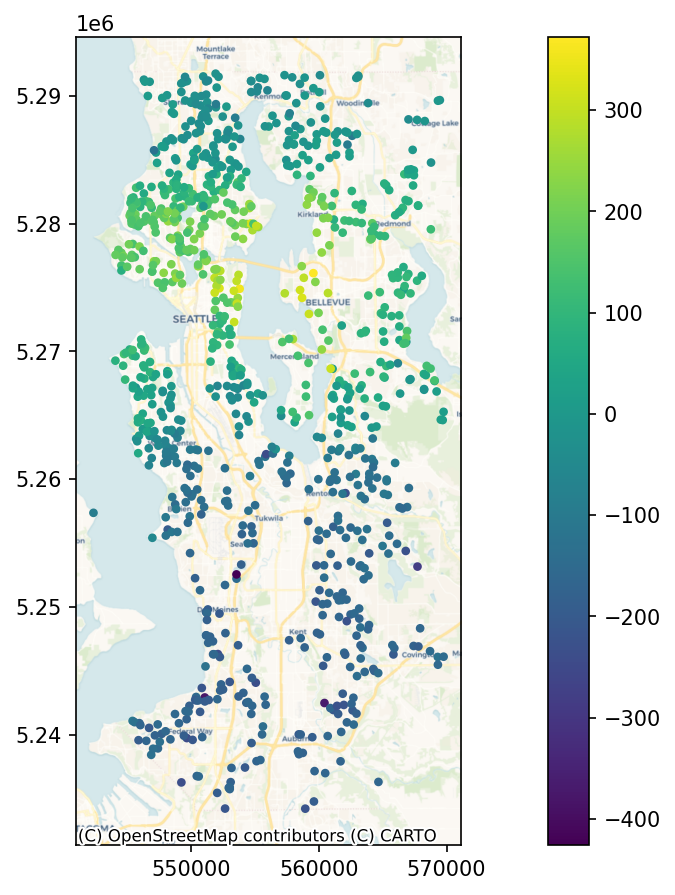

In [38]:
fig, ax = plt.subplots(1, 1,figsize=(15,7),dpi=150)

sea_map.plot(ax=ax, column=shap_values[:,-1].values + shap_values[:,-2].values,legend=True,s=10)


cx.add_basemap(ax=ax, source=cx.providers.CartoDB.Voyager, crs=sea_map.crs,zoom=11)

Northern Seattle neighborhoods and Bellevue are more desired locations.